In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from urllib.parse import urlparse

# 设置图表风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 针对可能存在的中文标题，防止乱码
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 修改为你实际的数据路径
data_path = "data/dataset_businessnewsdaily/clean/rag_chunks/chunks.csv"

# 加载数据，处理空值
df = pd.read_csv(data_path).fillna("")
df['chunk_text'] = df['chunk_text'].astype(str)

# 查看数据基本信息
print(f"共加载 {len(df)} 个文本切片。")
df.head(3)

共加载 16942 个文本切片。


,chunk_id,doc_id,url,title,chunk_index,chunk_len,chunk_text
0,doc_00001_chunk_001,doc_00001,https://www.businessnewsdaily.com/15859-how-to...,How to Develop Successful Email Drip Campaigns,1,771,Email marketing is a great way to engage with ...
1,doc_00001_chunk_002,doc_00001,https://www.businessnewsdaily.com/15859-how-to...,How to Develop Successful Email Drip Campaigns,2,883,sent automatically based on a set schedule or ...
2,doc_00001_chunk_003,doc_00001,https://www.businessnewsdaily.com/15859-how-to...,How to Develop Successful Email Drip Campaigns,3,802,s are a great way to stay top of mind with you...


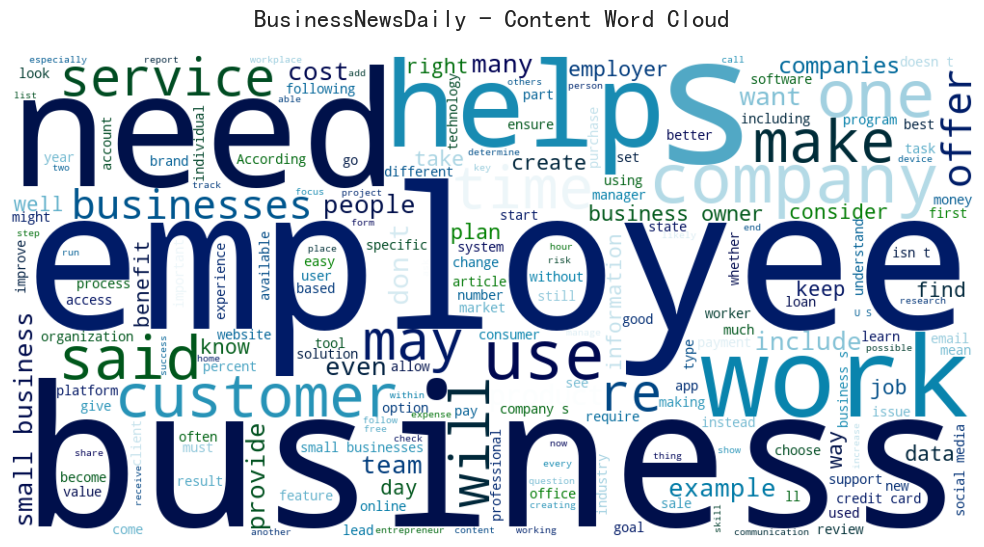

In [19]:
# 1. 将所有切片的文本拼接在一起
all_text = " ".join(df['chunk_text'].tolist())

# 2. 生成词云 (可以自定义背景颜色、最大词汇量等)
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    max_words=200,
    colormap='ocean'
).generate(all_text)

# 3. 绘制并显示
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('BusinessNewsDaily - Content Word Cloud', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

C:\Users\starl\AppData\Local\Temp\ipykernel_3508\1148281950.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_density, x='text_length', y='short_title', palette='magma')


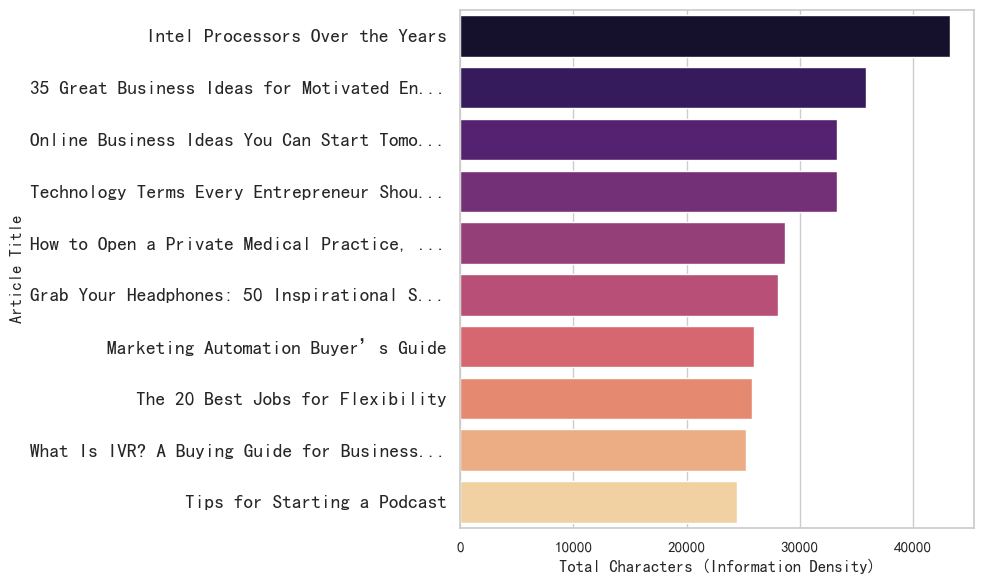

In [18]:
# 计算每个文本块的字符长度
df['text_length'] = df['chunk_text'].apply(len)

# 按照 URL 和 标题 对文章的字符长度进行求和汇总
article_stats = df.groupby(['url', 'title'])['text_length'].sum().reset_index()

# 提取总字数排名 Top 10 的文章
top_10_density = article_stats.sort_values(by='text_length', ascending=False).head(10)

# 截断过长的文章标题以便在图表中完美显示
top_10_density['short_title'] = top_10_density['title'].apply(lambda x: x[:40] + '...' if len(x) > 40 else x)

# 绘制条形图
plt.figure(figsize=(10, 6))
plt.yticks(fontsize=14)  # 你可以把 14 改成你想要的字号大小
sns.barplot(data=top_10_density, x='text_length', y='short_title', palette='magma')
#plt.title('Top 10 Pages by Information Density (Total Characters)', fontsize=15)
plt.xlabel('Total Characters (Information Density)', fontsize=12)
plt.ylabel('Article Title', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\starl\AppData\Local\Temp\ipykernel_3508\178514173.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.values, y=type_counts.index, palette='mako')


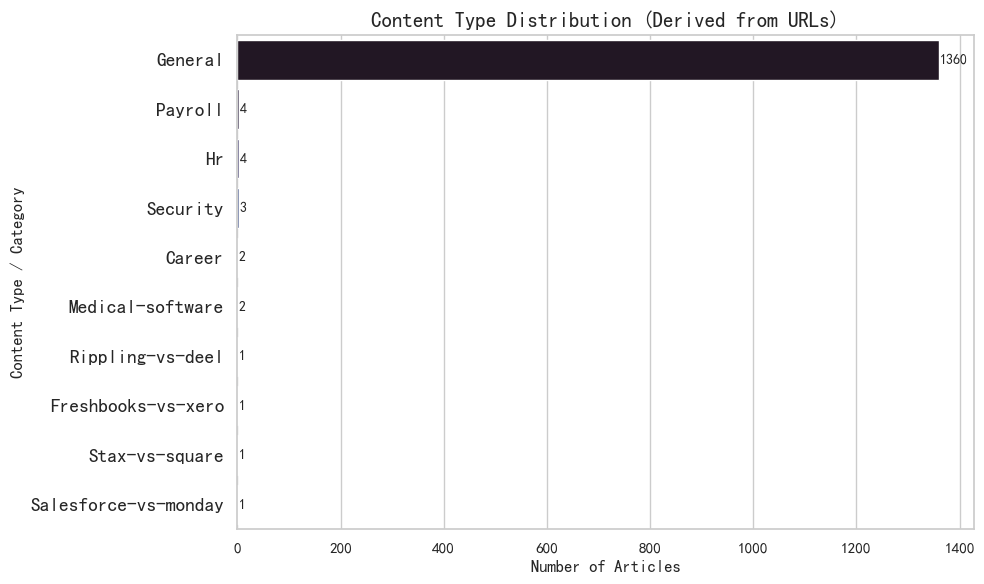

In [15]:
# 定义一个函数，从 URL 中提取一级目录作为类别
def extract_category(url):
    try:
        path = urlparse(url).path
        parts = [p for p in path.split('/') if p]
        if len(parts) > 0 and not parts[0].endswith('.html'):
            return parts[0].capitalize() # 提取第一个路径片段并大写首字母
        return 'General'
    except:
        return 'Unknown'

# 去重，确保我们计算的是“文章数”而不是“切片数”
unique_articles = df.drop_duplicates(subset=['url']).copy()
unique_articles['content_type'] = unique_articles['url'].apply(extract_category)

# 统计各类型的数量，取 Top 10
type_counts = unique_articles['content_type'].value_counts().head(10)

# 绘制水平条形图
plt.figure(figsize=(10, 6))
sns.barplot(x=type_counts.values, y=type_counts.index, palette='mako')
plt.title('Content Type Distribution (Derived from URLs)', fontsize=15)
plt.xlabel('Number of Articles', fontsize=12)
plt.ylabel('Content Type / Category', fontsize=12)
plt.tight_layout()

# 在柱状图上添加数值标签
for index, value in enumerate(type_counts.values):
    plt.text(value + 1, index, str(value), va='center', fontsize=10)

plt.show()

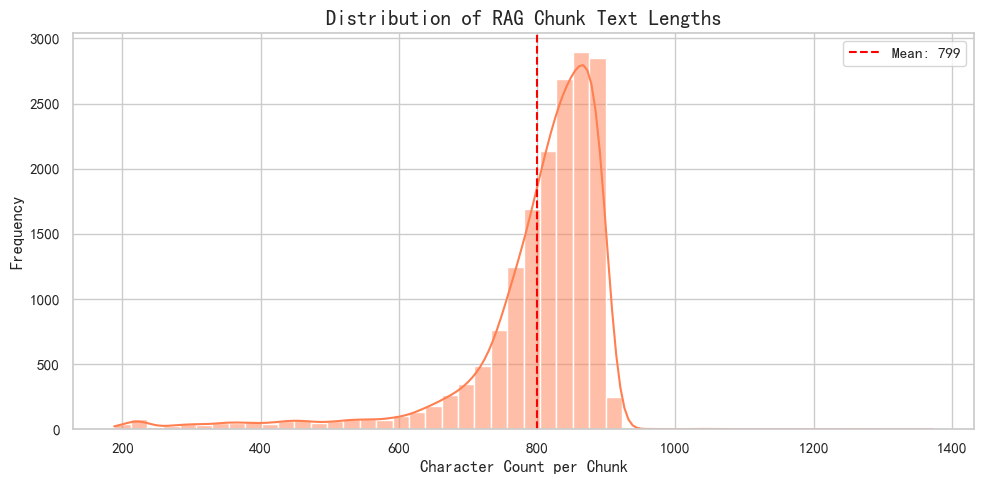

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['text_length'], bins=50, kde=True, color='coral')
plt.title('Distribution of RAG Chunk Text Lengths', fontsize=15)
plt.xlabel('Character Count per Chunk', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()